# CMU Data Science Club Datathon 2026

---



**Team Name:** avijayra

**Names:** Avnith Vijayram, Aiden Feyerherm, Eric Xue

**Andrew IDs:** avijayra, afeyerhe, ericxue


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

In [0]:
!pip install gdown

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
#!gdown 1P1BRPe-SqRnJohCF6L4SabPx4iI8BJ86 -O ../data/geo_mismatch/
#!unzip ../data/geo_mismatch/geo_mismatch_data.zip -d ../data/geo_mismatch/

In [0]:
DATA_PATH = "../data/geo_mismatch/*.csv" 

csv_files = glob.glob(DATA_PATH)
dataframes = {}

for file in csv_files:
    name = os.path.splitext(os.path.basename(file))[0]
    dataframes[name] = pd.read_csv(file)

    print(f"Loaded: {name}")
    # print(dataframes[name].columns)

Loaded: humanitarian-response-plans
Loaded: hpc_hno_2026
Loaded: hpc_hno_2025
Loaded: hpc_hno_2024
Loaded: cod_population_admin2
Loaded: cod_population_admin3
Loaded: cod_population_admin1
Loaded: cod_population_admin0
Loaded: cod_population_admin4



### Needed columns: 
startDate, duration, origRequirements, locations, category, population, 
### Dependent variable: 
(revisedRequirements - origRequirements) / origRequirements

In [0]:
from datetime import datetime

df_hrp = dataframes["humanitarian-response-plans"]

df = df_hrp[['startDate', 'endDate', 'origRequirements', 'revisedRequirements', 'categories', 'locations']][1:]

print(df.isna().sum())
print(df.shape)
df

startDate               0
endDate                 0
origRequirements        0
revisedRequirements     0
categories              0
locations              23
dtype: int64
(910, 6)


,startDate,endDate,origRequirements,revisedRequirements,categories,locations
1,2026-01-01,2026-12-31,880327426,880327426,Humanitarian needs and response plan | cluster...,HTI
2,2026-01-01,2026-12-31,4064305808,4064305808,cluster | en | Flash appeal,PSE
3,2026-01-01,2026-04-30,64943910,64943910,sector | en | Other,PAK
4,2026-01-01,2026-12-31,889600798,889600798,Humanitarian needs and response plan | cluster...,MMR
5,2026-01-01,2026-12-31,0,516000000,Humanitarian needs and response plan | sector ...,NGA
...,...,...,...,...,...,...
906,2000-01-01,2000-12-31,313757503,313757503,Consolidated inter-agency appeal,PRK
907,2000-01-01,2000-12-31,70961440,64338048,Consolidated inter-agency appeal,SLE
908,1999-12-01,2000-12-31,51596756,51596756,Consolidated inter-agency appeal,RUS
909,1999-10-01,2000-12-31,198631099,179660556,Consolidated inter-agency appeal,TLS


In [0]:
df = df.dropna()

# Convert origRequirements and revisedRequirements to float
df['origRequirements'] = df['origRequirements'].astype(float)
df['revisedRequirements'] = df['revisedRequirements'].astype(float)

# Remove rows where origRequirements == 0
df = df[df['origRequirements'] != 0]
df = df[df['revisedRequirements'] != 0]
df = df[pd.to_datetime(df['startDate']).dt.year != 2026]

df['year'] = pd.to_datetime(df['startDate']).dt.year

# Add duration column (difference in years between startDate and endDate)
df['duration'] = (pd.to_datetime(df['endDate']) - pd.to_datetime(df['startDate'])).dt.days / 365.25

revised = df['revisedRequirements']
original = df['origRequirements']

comparison = np.where(revised < original, 'Revised < Original',
              np.where(revised == original, 'Revised = Original', 'Revised > Original'))
df['comparison'] = comparison

In [0]:
def extract_types(cat_str):
    if pd.isnull(cat_str):
        assert False
        return pd.Series({'emergency_type': '', 'response_type': ''})
    parts = [p for p in cat_str.split(' | ') if p not in {'en', 'es', 'fr'}]
    if len(parts) == 1:
        return pd.Series({'emergency_type': parts[0], 'response_type': ''})
    elif len(parts) == 2:
        em_type = next((p for p in parts if p and p[0].isupper()), '')
        resp_type = next((p for p in parts if p != em_type), '')
        return pd.Series({'emergency_type': em_type, 'response_type': resp_type})
    else:
        assert False
        return pd.Series({'emergency_type': '', 'response_type': ''})

df[['emergency_type', 'response_type']] = df['categories'].apply(extract_types)

In [0]:
df = df.dropna(subset=['locations']).copy()
df['locations'] = df['locations'].str.split(' \| ')
df = df.explode('locations').reset_index(drop=True)
df.drop("categories", axis=1, inplace=True)
display(df)

startDate,endDate,origRequirements,revisedRequirements,locations,year,duration,comparison,emergency_type,response_type
2025-12-11,2026-04-30,3.53E7,3.53E7,LKA,2025,0.38329911019849416,Revised = Original,Other,sector
2025-10-28,2025-12-31,2.6591473E7,3.5036655E7,VNM,2025,0.17522245037645448,Revised > Original,Other,sector
2025-10-20,2025-12-31,8.568718E7,8.568718E7,PAK,2025,0.1971252566735113,Revised = Original,Other,sector
2025-04-01,2025-12-31,2.75150034E8,2.75150034E8,MMR,2025,0.7501711156741958,Revised = Original,Humanitarian needs and response plan,cluster
2025-01-01,2025-12-31,3.26056578E8,3.26056578E8,CAF,2025,0.9965776865160849,Revised = Original,Humanitarian needs and response plan,cluster
2025-01-01,2025-12-31,2.538016151E9,2.538016151E9,COD,2025,0.9965776865160849,Revised = Original,Humanitarian needs and response plan,cluster
2025-01-01,2025-12-31,6.11760722E8,6.11760722E8,LBY,2025,0.9965776865160849,Revised = Original,Regional response plan,sector
2025-01-01,2025-12-31,6.11760722E8,6.11760722E8,UGA,2025,0.9965776865160849,Revised = Original,Regional response plan,sector
2025-01-01,2025-12-31,6.11760722E8,6.11760722E8,EGY,2025,0.9965776865160849,Revised = Original,Regional response plan,sector
2025-01-01,2025-12-31,6.11760722E8,6.11760722E8,ETH,2025,0.9965776865160849,Revised = Original,Regional response plan,sector


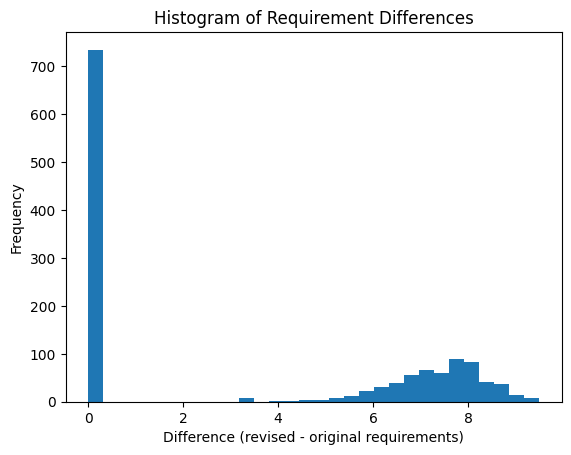

In [0]:
diffs = np.log10(1 + (df['revisedRequirements'].astype(float) - df['origRequirements'].astype(float)).abs())
plt.hist(diffs, bins=30)
plt.xlabel('Difference (revised - original requirements)')
plt.ylabel('Frequency')
plt.title('Histogram of Requirement Differences')
plt.show()

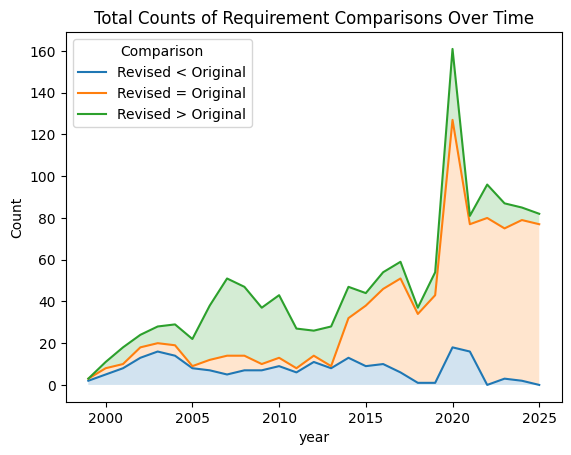

In [0]:
def plot_yearly_requirement_comparison(df):
    revised = df['revisedRequirements'].astype(float)
    original = df['origRequirements'].astype(float)
    
    yearly_counts = df.groupby(['year', 'comparison']).size().unstack(fill_value=0)

    ax = yearly_counts.plot(kind='line', stacked=True)
    plt.ylabel('Count')
    plt.title('Total Counts of Requirement Comparisons Over Time')
    plt.legend(title='Comparison')

    for i, col in enumerate(yearly_counts.columns):
        if i == 0:
            ax.fill_between(yearly_counts.index, 0, yearly_counts[col], alpha=0.2)
        else:
            prev = yearly_counts.iloc[:, :i].sum(axis=1)
            ax.fill_between(yearly_counts.index, prev, prev + yearly_counts[col], alpha=0.2)

    plt.show()

plot_yearly_requirement_comparison(df)

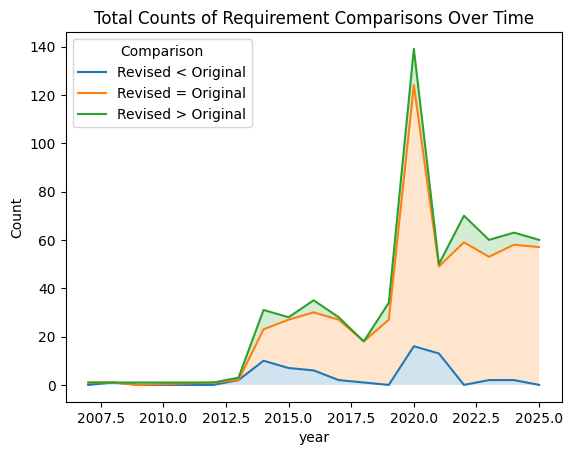

In [0]:
plot_yearly_requirement_comparison(df[df['response_type'] == 'sector'])

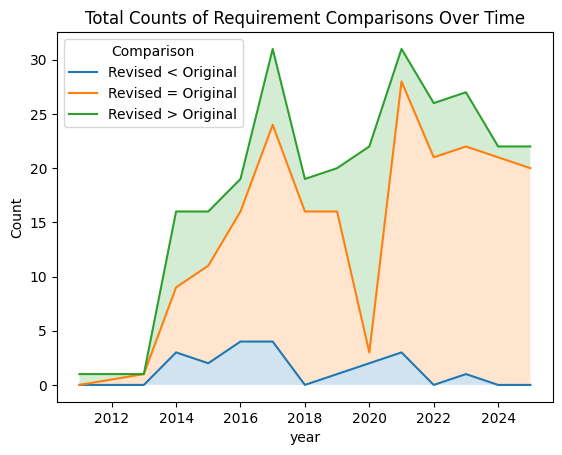

In [0]:
plot_yearly_requirement_comparison(df[df['response_type'] == 'cluster'])

In [0]:
display(df['comparison'].value_counts())

Revised = Original    735
Revised > Original    379
Revised < Original    205
Name: comparison, dtype: int64

In [0]:
display(df.dtypes)

startDate               object
endDate                 object
origRequirements       float64
revisedRequirements    float64
locations               object
year                     int64
duration               float64
comparison              object
emergency_type          object
response_type           object
dtype: object

In [0]:
dataframes['hpc_hno_2026']['year'] = 2026
dataframes['hpc_hno_2025']['year'] = 2025
dataframes['hpc_hno_2024']['year'] = 2024

df_hpc = pd.concat([dataframes['hpc_hno_2026'][1:], dataframes['hpc_hno_2025'][1:], dataframes['hpc_hno_2024'][1:]], ignore_index=True)

df_hpc.head(n=20)

,Country ISO3,Description,Cluster,Category,Population,In Need,Targeted,Affected,Reached,Info,year,Admin 1 PCode,Admin 1 Name,Admin 2 PCode,Admin 2 Name,Admin 3 PCode,Admin 3 Name
0,AFG,Plan caseload,ALL,NaN,48595632,21889283,17479657,NaN,NaN,NaN,2026,NaN,NaN,NaN,NaN,NaN,NaN
1,BFA,GHO Estimates,ALL,NaN,24100000,4400000,3100000,NaN,NaN,NaN,2026,NaN,NaN,NaN,NaN,NaN,NaN
2,CAF,Final,ALL,NaN,6567382,2286959,1265483,NaN,NaN,NaN,2026,NaN,NaN,NaN,NaN,NaN,NaN
3,CAF,CCCM,CCM,NaN,NaN,411618,246970,NaN,NaN,NaN,2026,NaN,NaN,NaN,NaN,NaN,NaN
4,CAF,Education,EDU,NaN,NaN,585470,278834,NaN,NaN,NaN,2026,NaN,NaN,NaN,NaN,NaN,NaN
5,CAF,Sécurité alimentaire,FSC,NaN,NaN,1765978,825257,NaN,NaN,NaN,2026,NaN,NaN,NaN,NaN,NaN,NaN
6,CAF,Santé,HEA,NaN,NaN,955008,516609,NaN,NaN,NaN,2026,NaN,NaN,NaN,NaN,NaN,NaN
7,CAF,Transfert d’espèces à usages multiples,MPC,NaN,NaN,NaN,39529,NaN,NaN,NaN,2026,NaN,NaN,NaN,NaN,NaN,NaN
8,CAF,Réponse aux réfugiés,MS,NaN,NaN,73000,73000,NaN,NaN,NaN,2026,NaN,NaN,NaN,NaN,NaN,NaN
9,CAF,Nutrition,NUT,NaN,NaN,335305,240392,NaN,NaN,NaN,2026,NaN,NaN,NaN,NaN,NaN,NaN


In [0]:
dups = df_hpc_all['year'].value_counts()
print("Max dup count:", dups.max())
print("Num ISO3 with dupes:", (dups > 1).sum())
print(dups[dups > 1].head(20))

Max dup count: 24
Num ISO3 with dupes: 3
2024    24
2025    22
2026    20
Name: year, dtype: int64


In [0]:
df_hpc_all[df_hpc_all['Country ISO3'] == 'AFG'].head()

,Country ISO3,year,Population,In Need
0,AFG,2024,44532600,23666389
1,AFG,2025,46024352,22887726
2,AFG,2026,48595632,21889283


In [0]:
df_cod = pd.concat(
    [dataframes[k][1:] for k in [
        'cod_population_admin2',
        'cod_population_admin3',
        'cod_population_admin1',
        'cod_population_admin0',
        'cod_population_admin4'
    ]],
    ignore_index=True
)[1:]

df_cod.head()

,ISO3,Country,ADM1_PCODE,ADM1_NAME,ADM2_PCODE,ADM2_NAME,ADM3_PCODE,ADM3_NAME,ADM4_PCODE,ADM4_NAME,Population_group,Gender,Age_range,Age_min,Age_max,Population,Reference_year,Source,Contributor
1,AGO,Angola,AO01,Bengo,AO01001,Ambriz,NaN,NaN,NaN,NaN,M_TL,m,all,NaN,NaN,17667,2024,Institut National de la Statistique et de l'An...,UNFPA
2,AGO,Angola,AO01,Bengo,AO01001,Ambriz,NaN,NaN,NaN,NaN,T_TL,all,all,NaN,NaN,32769,2024,Institut National de la Statistique et de l'An...,UNFPA
3,AGO,Angola,AO01,Bengo,AO01001,Ambriz,NaN,NaN,NaN,NaN,F_00_04,f,0-4,0,4,2877,2024,Institut National de la Statistique et de l'An...,UNFPA
4,AGO,Angola,AO01,Bengo,AO01001,Ambriz,NaN,NaN,NaN,NaN,F_05_09,f,5-9,5,9,2337,2024,Institut National de la Statistique et de l'An...,UNFPA
5,AGO,Angola,AO01,Bengo,AO01001,Ambriz,NaN,NaN,NaN,NaN,F_10_14,f,10-14,10,14,1860,2024,Institut National de la Statistique et de l'An...,UNFPA


In [0]:
df_cod['ISO3'] = df_cod['ISO3'].astype(str).str[:3]
df_cod['Reference_year'] = df_cod['Reference_year'].astype(int)

grouped = df_cod.groupby(['ISO3', 'Reference_year'])
total_population = grouped.apply(lambda g: g.loc[g['Population_group'] == 'T_TL', 'Population'].astype(float).sum())
male_population = grouped.apply(lambda g: g.loc[g['Population_group'] == 'M_TL', 'Population'].astype(float).sum())
percent_male = male_population / total_population

df_cod_preprocessed = pd.DataFrame({
    'ISO3': total_population.index.get_level_values('ISO3'),
    'Reference_year': total_population.index.get_level_values('Reference_year'),
    'total_population': total_population.values,
    'percent_male': percent_male.values
})

df_cod_preprocessed[df_cod_preprocessed['ISO3'] == 'SDN'].head()

,ISO3,Reference_year,total_population,percent_male
107,SDN,2024,142543587.0,0.500005


In [0]:
iso3_freq = df_cod_preprocessed['ISO3'].value_counts().sort_values(ascending=False)
display(iso3_freq)

SVK    2
MNG    2
GUY    1
ATG    1
AZE    1
      ..
TZA    1
TUR    1
TUN    1
VCT    1
ZWE    1
Name: ISO3, Length: 143, dtype: int64

In [0]:
#df = df.merge(
#    df_cod_preprocessed[['ISO3', 'total_population', 'percent_male']],
#    left_on='locations',
#    right_on='ISO3',
#    how='left'
#)
#print(df.shape)
#df.head()

In [0]:
df.shape

(1319, 10)

In [0]:
print(df_hpc[(df_hpc['Cluster']=='ALL') & (df_hpc['Description']=='Final HRP caseload') & (df_hpc['Country ISO3']=='AFG')]['Category'].value_counts().sort_values(ascending=False))

Adults                                                       436
Boys                                                         436
Men                                                          436
Girls                                                        436
Female-Headed Households                                     436
People with Disabilities                                     436
Children                                                     436
total                                                        436
Elderly                                                      436
Sudden-Onset Natural Disaster-Affected (2025) - Boys         436
Sudden-Onset Natural Disaster-Affected (2025) - Girls        436
Sudden-Onset Natural Disaster-Affected (2025) - Men          436
Sudden-Onset Natural Disaster-Affected (2025) - Total        436
Total Households                                             436
Women                                                        436
Sudden-Onset Natural Disa

In [0]:
print(df['locations'].nunique())

126


In [0]:
freq = df_hpc[df_hpc['Cluster'] == 'ALL']['Country ISO3'].value_counts().sort_values(ascending=False)


df_hpc_selected = df_hpc[
    (df_hpc['Category'] == 'total') &
    (df_hpc['Cluster'] == 'ALL')
]

df_hpc_selected['In Need'] = pd.to_numeric(df_hpc['In Need'], errors='coerce')
df_hpc_selected['Population'] = pd.to_numeric(df_hpc_selected['Population'], errors='coerce')

df_hpc_selected['In Need'] = df_hpc_selected['In Need'].fillna(0)
df_hpc_selected['Population'] = df_hpc_selected['Population'].fillna(0)

df_hpc_agg = df_hpc_selected.groupby(['Country ISO3']).agg({
    'Population': 'sum',
    'In Need': 'sum'
}).reset_index()

df_hpc_agg['proportion_in_need'] = df_hpc_agg['In Need'] / df_hpc_agg['Population']

s = df_hpc_agg['proportion_in_need']

mean_no_inf = s.replace([np.inf, -np.inf], np.nan).mean()
df_hpc_agg['proportion_in_need'] = s.replace([np.inf, -np.inf], mean_no_inf)

df_hpc_agg.head(n=50)
print(df_hpc_selected.shape)




(7184, 17)


In [0]:
avg_prop = df_hpc_agg['proportion_in_need'].mean(skipna=True)
df_hpc_agg['proportion_in_need'] = df_hpc_agg['proportion_in_need'].fillna(avg_prop)

In [0]:
df_hpc_selected.shape

(7184, 17)

In [0]:
country_freq = df_hpc_agg['Country ISO3'].value_counts()
assert (country_freq == 1).all(), "Some countries appear more than once in df_hpc_agg"
display(country_freq)

AFG    1
NER    1
VEN    1
UKR    1
TCD    1
SYR    1
SSD    1
SOM    1
SLV    1
SDN    1
NGA    1
MOZ    1
BFA    1
MMR    1
MLI    1
HTI    1
HND    1
GTM    1
COL    1
COD    1
CMR    1
CAF    1
YEM    1
Name: Country ISO3, dtype: int64

In [0]:
df = df.merge(
    df_hpc_agg[['Country ISO3', 'proportion_in_need']],
    left_on='locations',
    right_on='Country ISO3',
    how='left'
)
print(df.shape)
df.head()


(1319, 12)


,startDate,endDate,origRequirements,revisedRequirements,locations,year,duration,comparison,emergency_type,response_type,Country ISO3,proportion_in_need
0,2025-12-11,2026-04-30,35300000.0,35300000.0,LKA,2025,0.383299,Revised = Original,Other,sector,NaN,NaN
1,2025-10-28,2025-12-31,26591473.0,35036655.0,VNM,2025,0.175222,Revised > Original,Other,sector,NaN,NaN
2,2025-10-20,2025-12-31,85687180.0,85687180.0,PAK,2025,0.197125,Revised = Original,Other,sector,NaN,NaN
3,2025-04-01,2025-12-31,275150034.0,275150034.0,MMR,2025,0.750171,Revised = Original,Humanitarian needs and response plan,cluster,MMR,0.338839
4,2025-01-01,2025-12-31,326056578.0,326056578.0,CAF,2025,0.996578,Revised = Original,Humanitarian needs and response plan,cluster,CAF,0.461611


In [0]:
avg_prop = df['proportion_in_need'].mean(skipna=True)
df['proportion_in_need'] = df['proportion_in_need'].fillna(avg_prop)

In [0]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import OneHotEncoder

# Convert population_bin to string to avoid interval dtype issues
#df['population_bin'] = pd.qcut(df['total_population'], 5).astype(str)

#display(df['population_bin'])

X = df[['emergency_type', 'response_type', 'origRequirements', 'year', 'locations', 'duration']]
y = df['comparison']

# One hot encode string columns
string_cols = X.select_dtypes(include='object').columns
print(string_cols)
print(df.columns)
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
X_encoded = encoder.fit_transform(X[string_cols])
X_numeric = X.drop(columns=string_cols).astype(float).values
import numpy as np
X_final = np.hstack([X_numeric, X_encoded])

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=4243)

clf = DecisionTreeClassifier(
    random_state=262343579,
    class_weight="balanced"
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

display(pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Classification Report": [classification_report(y_test, y_pred, output_dict=False)]
}))

feature_names = list(X.drop(columns=string_cols).columns) + list(encoder.get_feature_names_out(string_cols))
tree_rules = export_text(clf, feature_names=feature_names)
print(tree_rules)


Index(['emergency_type', 'response_type', 'locations'], dtype='object')
Index(['startDate', 'endDate', 'origRequirements', 'revisedRequirements',
       'locations', 'year', 'duration', 'comparison', 'emergency_type',
       'response_type', 'Country ISO3', 'proportion_in_need'],
      dtype='object')


Accuracy,Classification Report
0.7840909090909091,precision recall f1-score support Revised < Original 0.57 0.60 0.59 45 Revised = Original 0.88 0.85 0.87 148 Revised > Original 0.73 0.76 0.74 71 accuracy 0.78 264 macro avg 0.73 0.74 0.73 264 weighted avg 0.79 0.78 0.79 264


|--- year <= 2014.50
|   |--- emergency_type_Regional response plan <= 0.50
|   |   |--- locations_TCD <= 0.50
|   |   |   |--- duration <= 0.91
|   |   |   |   |--- emergency_type_Other <= 0.50
|   |   |   |   |   |--- emergency_type_Consolidated inter-agency appeal <= 0.50
|   |   |   |   |   |   |--- locations_YEM <= 0.50
|   |   |   |   |   |   |   |--- locations_BFA <= 0.50
|   |   |   |   |   |   |   |   |--- origRequirements <= 211950264.00
|   |   |   |   |   |   |   |   |   |--- origRequirements <= 80891340.00
|   |   |   |   |   |   |   |   |   |   |--- year <= 2007.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 10
|   |   |   |   |   |   |   |   |   |   |--- year >  2007.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 8
|   |   |   |   |   |   |   |   |   |--- origRequirements >  80891340.00
|   |   |   |   |   |   |   |   |   |   |--- year <= 2007.00
|   |   |   |   |   |   |   |   |   |   |   |--- class: Revised 

In [0]:
# Get feature importances from the trained DecisionTreeClassifier
feature_names = list(X.drop(columns=string_cols).columns) + list(encoder.get_feature_names_out(string_cols))
importances = clf.feature_importances_

# Sort and display top features
top_indices = np.argsort(importances)[::-1]
top_features = [(feature_names[i], importances[i]) for i in top_indices[:10]]
display(pd.DataFrame(top_features, columns=["Feature", "Importance"]))

Feature,Importance
year,0.26963396370775194
origRequirements,0.2490825293848469
duration,0.08506229119130108
emergency_type_Regional response plan,0.07520274546183388
response_type_sector,0.019183172189390113
locations_YEM,0.014182724040167773
emergency_type_Humanitarian response plan,0.013782660252720562
locations_NER,0.012071934223005424
locations_,0.011024430666593149
emergency_type_Other,0.01048240946466284


In [0]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import OneHotEncoder

X = df[['emergency_type', 'response_type', 'origRequirements', 'year', 'locations', 'duration']]
y = df['comparison']

# One hot encode string columns
string_cols = list(X.select_dtypes(include='object').columns) + ['origRequirements']
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
X_encoded = encoder.fit_transform(X[string_cols])
X_numeric = X.drop(columns=string_cols).astype(float).values
import numpy as np
X_final = np.hstack([X_numeric, X_encoded])

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=4243)

clf = RandomForestClassifier(
    n_estimators = 10,
    random_state=98,
    class_weight="balanced"
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

import pandas as pd
display(pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Classification Report": [classification_report(y_test, y_pred, output_dict=False)]
}))

Accuracy,Classification Report
0.7727272727272727,precision recall f1-score support Revised < Original 0.71 0.49 0.58 45 Revised = Original 0.87 0.87 0.87 148 Revised > Original 0.63 0.75 0.68 71 accuracy 0.77 264 macro avg 0.74 0.70 0.71 264 weighted avg 0.78 0.77 0.77 264


In [0]:
# %pip install xgboost

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import xgboost as xgb

X = df[['emergency_type', 'response_type', 'origRequirements', 'year', 'locations', 'duration']]
y = df['comparison']

string_cols = X.select_dtypes(include='object').columns
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
X_encoded = encoder.fit_transform(X[string_cols])
X_numeric = X.drop(columns=string_cols).astype(float).values
import numpy as np
X_final = np.hstack([X_numeric, X_encoded])

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_final, y_encoded, test_size=0.2, random_state=4243)

accuracies = []
for n in range(1, 101):
    clf = xgb.XGBClassifier(
        n_estimators=n,
        random_state=745726,
        scale_pos_weight=1,
        use_label_encoder=False,
        eval_metric='mlogloss'
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(label_encoder.inverse_transform(y_test), label_encoder.inverse_transform(y_pred))
    accuracies.append((n, acc))

import pandas as pd
results_df = pd.DataFrame(accuracies, columns=["n_estimators", "Accuracy"])
display(results_df)

n_estimators,Accuracy
1,0.7689393939393939
2,0.7765151515151515
3,0.7992424242424242
4,0.803030303030303
5,0.803030303030303
6,0.821969696969697
7,0.8143939393939394
8,0.8068181818181818
9,0.803030303030303
10,0.8106060606060606


In [0]:
try:
    unique, counts = np.unique(label_encoder.inverse_transform(y_pred), return_counts=True)
    freq_df = pd.DataFrame({'String': unique, 'Frequency': counts})
    display(freq_df)
except ValueError as e:
    # Fallback: display encoded values directly
    unique, counts = np.unique(y, return_counts=True)
    freq_df = pd.DataFrame({'Encoded_Label': unique, 'Frequency': counts})
    print("Warning: Could not decode labels. Displaying encoded values.")
    display(freq_df)
    print(e)

String,Frequency
Revised < Original,40
Revised = Original,153
Revised > Original,71


In [0]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)


array([[ 27,   8,  10],
       [  4, 132,  12],
       [  9,  13,  49]])

In [0]:
for k in dataframes:
    display(dataframes[k].head())

code,internalId,startDate,endDate,planVersion,categories,locations,years,origRequirements,revisedRequirements
#response+code,#meta+id,#date+start,#date+end,#response+name,#response+type+list,#country+code+list,#date+year+list,#value+requirements+orig+c_usd,#value+requirements+revised+c_usd
HHTI26,8278,2026-01-01,2026-12-31,Haiti Besoins Humanitaires et Plan de Réponse 2026,Humanitarian needs and response plan | cluster | fr,HTI,2026,880327426,880327426
FPSE26,8267,2026-01-01,2026-12-31,Escalation of Hostilities in the OPT Flash Appeal 2026,cluster | en | Flash appeal,PSE,2026,4064305808,4064305808
OPAK26,8191,2026-01-01,2026-04-30,Pakistan Floods Support Plan 2026,sector | en | Other,PAK,2026,64943910,64943910
HMMR26,8308,2026-01-01,2026-12-31,Myanmar Humanitarian Needs and Response Plan 2026,Humanitarian needs and response plan | cluster | en,MMR,2026,889600798,889600798


Country ISO3,Description,Cluster,Category,Population,In Need,Targeted,Affected,Reached,Info,year
#country+code,#sector+description,#sector+cluster+code,#category,#population,#inneed,#targeted,#affected,#reached,#meta+info,2026
AFG,Plan caseload,ALL,null,48595632,21889283,17479657,null,null,null,2026
BFA,GHO Estimates,ALL,null,24100000,4400000,3100000,null,null,null,2026
CAF,Final,ALL,null,6567382,2286959,1265483,null,null,null,2026
CAF,CCCM,CCM,null,null,411618,246970,null,null,null,2026


Country ISO3,Admin 1 PCode,Admin 1 Name,Admin 2 PCode,Admin 2 Name,Admin 3 PCode,Admin 3 Name,Description,Cluster,Category,Population,In Need,Targeted,Affected,Reached,Info,year
#country+code,#adm1+code,#adm1+name,#adm2+code,#adm2+name,#adm3+code,#adm3+name,#sector+description,#sector+cluster+code,#category,#population,#inneed,#targeted,#affected,#reached,#meta+info,2025
AFG,null,null,null,null,null,null,Final HRP caseload,ALL,null,46024352,22887726,16790412,null,18100000,null,2025
AFG,null,null,null,null,null,null,Final HRP caseload,ALL,Adults,20999996,10241973,7737415,null,null,null,2025
AFG,null,null,null,null,null,null,Final HRP caseload,ALL,Boys,12241703,5927993,4431106,null,null,null,2025
AFG,null,null,null,null,null,null,Final HRP caseload,ALL,Children,24035916,12188191,8707494,null,null,null,2025


Country ISO3,Admin 1 PCode,Admin 1 Name,Admin 2 PCode,Admin 2 Name,Admin 3 PCode,Admin 3 Name,Description,Cluster,Category,Population,In Need,Targeted,Affected,Reached,Info,year
#country+code,#adm1+code,#adm1+name,#adm2+code,#adm2+name,#adm3+code,#adm3+name,#sector+description,#sector+cluster+code,#category,#population,#inneed,#targeted,#affected,#reached,#meta+info,2024
AFG,null,null,null,null,null,null,Final HNRP Caseload,ALL,null,44532600,23666389,17327995,null,18400000,null,2024
AFG,null,null,null,null,null,null,Final HNRP Caseload,ALL,Adult,null,10876422,7982696,null,null,null,2024
AFG,null,null,null,null,null,null,Final HNRP Caseload,ALL,Adult - Female,null,5857561,4090179,null,null,null,2024
AFG,null,null,null,null,null,null,Final HNRP Caseload,ALL,Adult - Female - Border / EC,null,184946,164215,null,null,null,2024


ISO3,Country,ADM1_PCODE,ADM1_NAME,ADM2_PCODE,ADM2_NAME,ADM3_PCODE,ADM3_NAME,ADM4_PCODE,ADM4_NAME,Population_group,Gender,Age_range,Age_min,Age_max,Population,Reference_year,Source,Contributor
#country+code,#country+name,#adm1+code,#adm1+name,#adm2+code,#adm2+name,#adm3+code,#adm3+name,#adm4+code,#adm4+name,#population+group,#gender,#age+range,#age+min,#age+max,#population,#date+year,#meta+source,#meta+contributor
AGO,Angola,AO01,Bengo,AO01001,Ambriz,null,null,null,null,F_TL,f,all,null,null,15102,2024,Institut National de la Statistique et de l'Analyse Economique (baseline); US Census Bureau (projections),UNFPA
AGO,Angola,AO01,Bengo,AO01001,Ambriz,null,null,null,null,M_TL,m,all,null,null,17667,2024,Institut National de la Statistique et de l'Analyse Economique (baseline); US Census Bureau (projections),UNFPA
AGO,Angola,AO01,Bengo,AO01001,Ambriz,null,null,null,null,T_TL,all,all,null,null,32769,2024,Institut National de la Statistique et de l'Analyse Economique (baseline); US Census Bureau (projections),UNFPA
AGO,Angola,AO01,Bengo,AO01001,Ambriz,null,null,null,null,F_00_04,f,0-4,0,4,2877,2024,Institut National de la Statistique et de l'Analyse Economique (baseline); US Census Bureau (projections),UNFPA


ISO3,Country,ADM1_PCODE,ADM1_NAME,ADM2_PCODE,ADM2_NAME,ADM3_PCODE,ADM3_NAME,ADM4_PCODE,ADM4_NAME,Population_group,Gender,Age_range,Age_min,Age_max,Population,Reference_year,Source,Contributor
#country+code,#country+name,#adm1+code,#adm1+name,#adm2+code,#adm2+name,#adm3+code,#adm3+name,#adm4+code,#adm4+name,#population+group,#gender,#age+range,#age+min,#age+max,#population,#date+year,#meta+source,#meta+contributor
BGD,Bangladesh,BD10,Barisal,BD1004,Barguna,BD100409,Amtali,null,null,F_TL,f,all,null,null,142076,2022,UNFPA and US Census Bureau (USCB),UNFPA
BGD,Bangladesh,BD10,Barisal,BD1004,Barguna,BD100409,Amtali,null,null,M_TL,m,all,null,null,126963,2022,UNFPA and US Census Bureau (USCB),UNFPA
BGD,Bangladesh,BD10,Barisal,BD1004,Barguna,BD100409,Amtali,null,null,T_TL,all,all,null,null,269039,2022,UNFPA and US Census Bureau (USCB),UNFPA
BGD,Bangladesh,BD10,Barisal,BD1004,Barguna,BD100409,Amtali,null,null,F_00_04,f,0-4,0,4,11119,2022,UNFPA and US Census Bureau (USCB),UNFPA


ISO3,Country,ADM1_PCODE,ADM1_NAME,ADM2_PCODE,ADM2_NAME,ADM3_PCODE,ADM3_NAME,ADM4_PCODE,ADM4_NAME,Population_group,Gender,Age_range,Age_min,Age_max,Population,Reference_year,Source,Contributor
#country+code,#country+name,#adm1+code,#adm1+name,#adm2+code,#adm2+name,#adm3+code,#adm3+name,#adm4+code,#adm4+name,#population+group,#gender,#age+range,#age+min,#age+max,#population,#date+year,#meta+source,#meta+contributor
ALB,Albania,AL01,Berat,null,null,null,null,null,null,F_TL,f,all,null,null,62842,2021,UNFPA,UNFPA
ALB,Albania,AL01,Berat,null,null,null,null,null,null,M_TL,m,all,null,null,61786,2021,UNFPA,UNFPA
ALB,Albania,AL01,Berat,null,null,null,null,null,null,T_TL,all,all,null,null,124628,2021,UNFPA,UNFPA
ALB,Albania,AL01,Berat,null,null,null,null,null,null,F_00_04,f,0-4,0,4,3125,2021,UNFPA,UNFPA


ISO3,Country,ADM1_PCODE,ADM1_NAME,ADM2_PCODE,ADM2_NAME,ADM3_PCODE,ADM3_NAME,ADM4_PCODE,ADM4_NAME,Population_group,Gender,Age_range,Age_min,Age_max,Population,Reference_year,Source,Contributor
#country+code,#country+name,#adm1+code,#adm1+name,#adm2+code,#adm2+name,#adm3+code,#adm3+name,#adm4+code,#adm4+name,#population+group,#gender,#age+range,#age+min,#age+max,#population,#date+year,#meta+source,#meta+contributor
AFG,Afghanistan,null,null,null,null,null,null,null,null,F_TL,f,all,null,null,19844212,2021,National Statistic and Information Authority (NSIA) Afghanistan,OCHA Afghanistan
AFG,Afghanistan,null,null,null,null,null,null,null,null,M_TL,m,all,null,null,20567657,2021,National Statistic and Information Authority (NSIA) Afghanistan,OCHA Afghanistan
AFG,Afghanistan,null,null,null,null,null,null,null,null,T_TL,all,all,null,null,40411869,2021,National Statistic and Information Authority (NSIA) Afghanistan,OCHA Afghanistan
AFG,Afghanistan,null,null,null,null,null,null,null,null,F_00_04,f,0-4,0,4,3571135,2021,National Statistic and Information Authority (NSIA) Afghanistan,OCHA Afghanistan


ISO3,Country,ADM1_PCODE,ADM1_NAME,ADM2_PCODE,ADM2_NAME,ADM3_PCODE,ADM3_NAME,ADM4_PCODE,ADM4_NAME,Population_group,Gender,Age_range,Age_min,Age_max,Population,Reference_year,Source,Contributor
#country+code,#country+name,#adm1+code,#adm1+name,#adm2+code,#adm2+name,#adm3+code,#adm3+name,#adm4+code,#adm4+name,#population+group,#gender,#age+range,#age+min,#age+max,#population,#date+year,#meta+source,#meta+contributor
MDG,Madagascar,MG11,Analamanga,MG11101001A,1er Arrondissement,MG11101001,1er Arrondissement,MG11101001001,Antanimalalaka Analakely,T_TL,all,all,null,null,1347,2018,INSTAT / Madagascar BNGRC (National Disaster Management Agency ) 2009 population data,OCHA Regional Office for Southern and Eastern Africa (ROSEA)
MDG,Madagascar,MG11,Analamanga,MG11101001A,1er Arrondissement,MG11101001,1er Arrondissement,MG11101001002,Ambalavao Isotry,T_TL,all,all,null,null,6436,2018,INSTAT / Madagascar BNGRC (National Disaster Management Agency ) 2009 population data,OCHA Regional Office for Southern and Eastern Africa (ROSEA)
MDG,Madagascar,MG11,Analamanga,MG11101001A,1er Arrondissement,MG11101001,1er Arrondissement,MG11101001003,Ambatonakanga Ambohitsorohitra,T_TL,all,all,null,null,2151,2018,INSTAT / Madagascar BNGRC (National Disaster Management Agency ) 2009 population data,OCHA Regional Office for Southern and Eastern Africa (ROSEA)
MDG,Madagascar,MG11,Analamanga,MG11101001A,1er Arrondissement,MG11101001,1er Arrondissement,MG11101001004,Ambatovinaky,T_TL,all,all,null,null,3804,2018,INSTAT / Madagascar BNGRC (National Disaster Management Agency ) 2009 population data,OCHA Regional Office for Southern and Eastern Africa (ROSEA)


In [0]:
for k in dataframes:
    print(len(dataframes[k]))

911
64
318260
387820
1001584
241963
91472
6723
17466


In [0]:
display(list(dataframes.keys()))

_1
humanitarian-response-plans
hpc_hno_2026
hpc_hno_2025
hpc_hno_2024
cod_population_admin2
cod_population_admin3
cod_population_admin1
cod_population_admin0
cod_population_admin4


In [0]:
display(list(dataframes.keys()))

_1
humanitarian-response-plans
hpc_hno_2026
hpc_hno_2025
hpc_hno_2024
cod_population_admin2
cod_population_admin3
cod_population_admin1
cod_population_admin0
cod_population_admin4


In [0]:
tree = clf.tree_
classes = clf.classes_

# Map original class labels to symbols
class_map = {
    "Revised < Original": "<",
    "Revised = Original": "=",
    "Revised > Original": ">"
}
mapped_classes = [class_map.get(cls, cls) for cls in classes]

def fmt_counts(node):
    c = tree.value[node][0]
    return "[" + ", ".join(f"{mapped_classes[i]}:{c[i]:.0f}" for i in range(len(classes))) + "]"

def walk(node=0, depth=0):
    indent = "|   " * depth

    if tree.children_left[node] == -1:
        pred_idx = tree.value[node][0].argmax()
        pred = mapped_classes[pred_idx]
        print(f"{indent}LEAF predict={pred} {fmt_counts(node)}")
        return

    feat = feature_names[tree.feature[node]]
    thr = tree.threshold[node]
    left = tree.children_left[node]
    right = tree.children_right[node]

    print(f"{indent}if {feat} <= {thr:.3f}: {fmt_counts(left)}")
    walk(left, depth+1)
    print(f"{indent}else: {fmt_counts(right)}")
    walk(right, depth+1)

walk()

---------------------------------------------------------------------------
AttributeError                            Traceback (most recent call last)
File <command-8516054466660817>, line 1
----> 1 tree = clf.tree_
      2 classes = clf.classes_
      4 # Map original class labels to symbols

AttributeError: 'XGBClassifier' object has no attribute 'tree_'

Green color is assigned to response_type: 


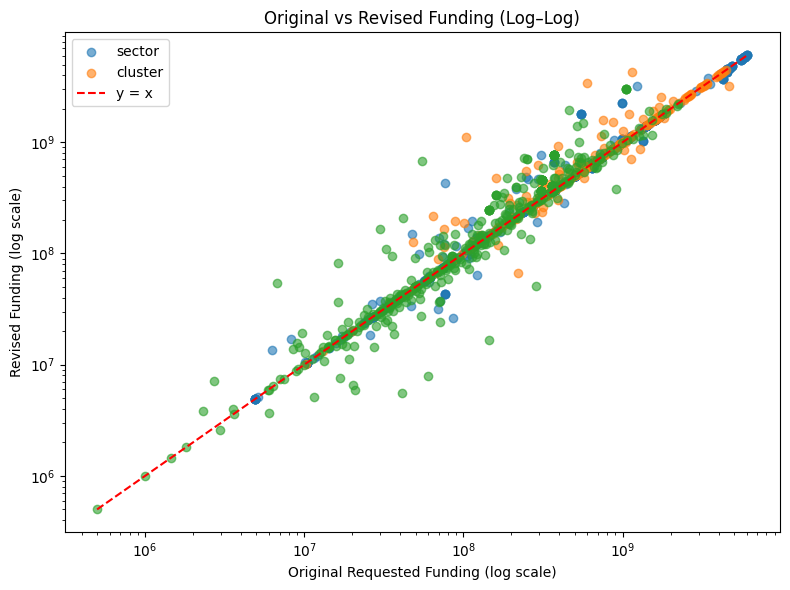

In [0]:
import matplotlib.pyplot as plt
import numpy as np

df['change'] = df['revisedRequirements'] - df['origRequirements']

# keep only positive values (log-safe)
log_df = df[
    (df['origRequirements'] > 0) &
    (df['revisedRequirements'] > 0)
]

plt.figure(figsize=(8, 6))

# Highlight data by response_type
response_types = log_df['response_type'].unique()
colors = plt.cm.tab10.colors
color_map = {rt: colors[i % len(colors)] for i, rt in enumerate(response_types)}

# Print which response_type is assigned green
green_rgb = colors[2]  # tab10 green is at index 2
for rt, col in color_map.items():
    if np.allclose(col, green_rgb):
        print(f"Green color is assigned to response_type: {rt}")

for rt in response_types:
    subset = log_df[log_df['response_type'] == rt]
    plt.scatter(
        subset['origRequirements'],
        subset['revisedRequirements'],
        alpha=0.6,
        label=rt,
        color=color_map[rt]
    )

# y = x line
min_val = min(
    log_df['origRequirements'].min(),
    log_df['revisedRequirements'].min()
)
max_val = max(
    log_df['origRequirements'].max(),
    log_df['revisedRequirements'].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    label='y = x'
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Original Requested Funding (log scale)')
plt.ylabel('Revised Funding (log scale)')
plt.title('Original vs Revised Funding (Log–Log)')
plt.legend()
plt.tight_layout()
plt.show()

Green color is assigned to emergency_type: Regional response plan


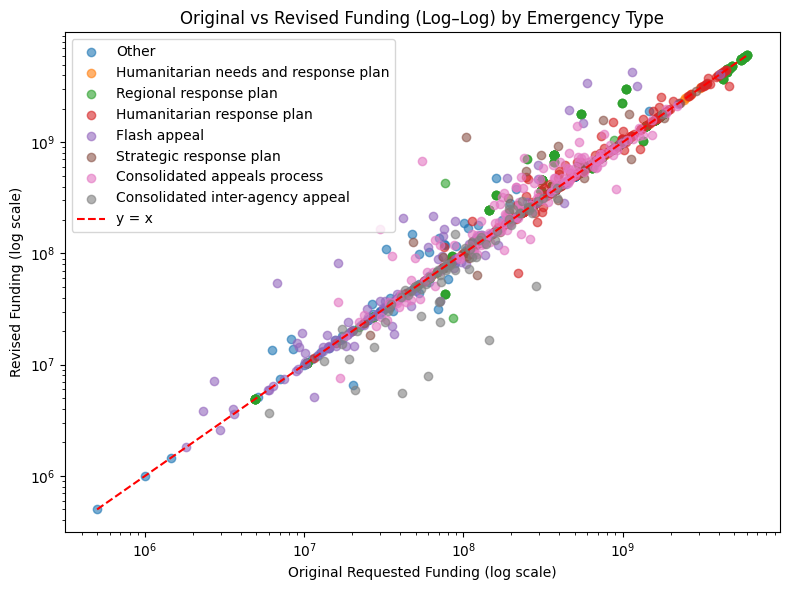

In [0]:
import matplotlib.pyplot as plt
import numpy as np

df['change'] = df['revisedRequirements'] - df['origRequirements']

# keep only positive values (log-safe)
log_df = df[
    (df['origRequirements'] > 0) &
    (df['revisedRequirements'] > 0)
]

plt.figure(figsize=(8, 6))

# Highlight data by emergency_type
emergency_types = log_df['emergency_type'].unique()
colors = plt.cm.tab10.colors
color_map = {et: colors[i % len(colors)] for i, et in enumerate(emergency_types)}

# Print which emergency_type is assigned green
green_rgb = colors[2]  # tab10 green is at index 2
for et, col in color_map.items():
    if np.allclose(col, green_rgb):
        print(f"Green color is assigned to emergency_type: {et}")

for et in emergency_types:
    subset = log_df[log_df['emergency_type'] == et]
    plt.scatter(
        subset['origRequirements'],
        subset['revisedRequirements'],
        alpha=0.6,
        label=et,
        color=color_map[et]
    )

# y = x line
min_val = min(
    log_df['origRequirements'].min(),
    log_df['revisedRequirements'].min()
)
max_val = max(
    log_df['origRequirements'].max(),
    log_df['revisedRequirements'].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    label='y = x'
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Original Requested Funding (log scale)')
plt.ylabel('Revised Funding (log scale)')
plt.title('Original vs Revised Funding (Log–Log) by Emergency Type')
plt.legend()
plt.tight_layout()
plt.show()

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate change per country
country_change = df.groupby('locations').agg({
    'revisedRequirements': 'sum',
    'origRequirements': 'sum'
})
country_change['change'] = country_change['revisedRequirements'] - country_change['origRequirements']
country_change.reset_index(inplace=True)

# Load world map data using plotly for choropleth
import plotly.express as px
import numpy as np

# Use log scale for 'change', keeping sign
country_change['log_change'] = np.sign(country_change['change']) * np.log1p(np.abs(country_change['change']))

fig = px.choropleth(
    country_change,
    locations='locations',
    color='log_change',
    color_continuous_scale='RdBu',
    locationmode='ISO-3',
    title='Change in Revised vs Original Funding by Country'
)
fig.update_geos(showcoastlines=True, showcountries=True, showland=True, fitbounds="locations")
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

Index(['startDate', 'endDate', 'origRequirements', 'revisedRequirements',
       'locations', 'year', 'duration', 'comparison', 'emergency_type',
       'response_type', 'Country ISO3', 'proportion_in_need', 'change'],
      dtype='object')


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


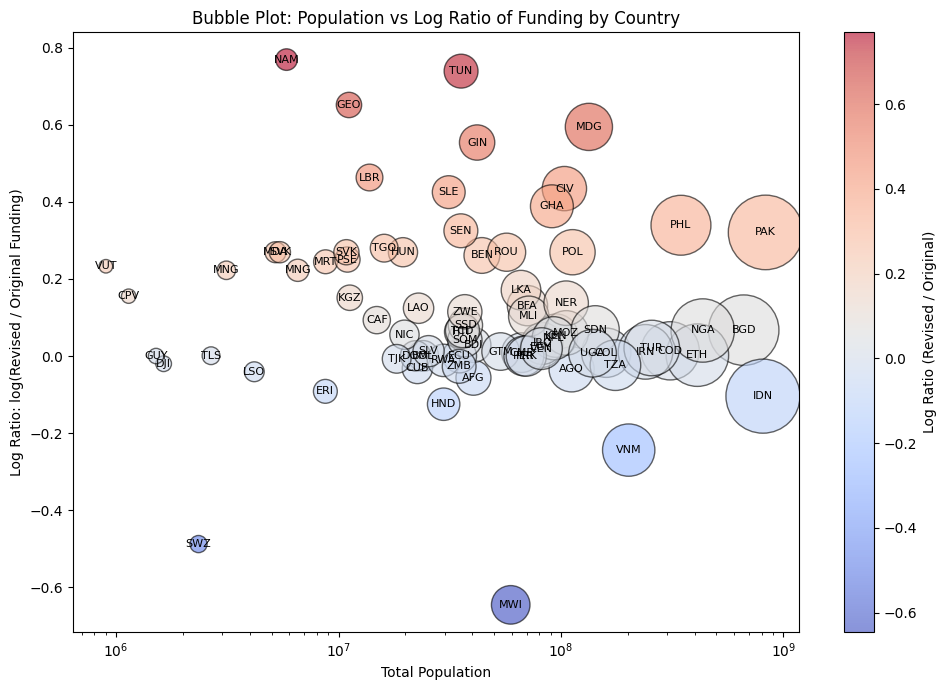

In [0]:
import matplotlib.pyplot as plt

print(df.columns)

# Merge country stats with population from df_cod_preprocessed
country_stats = df.groupby('locations').agg({
    'revisedRequirements': 'sum',
    'origRequirements': 'sum'
})
country_stats['change'] = country_stats['revisedRequirements'] - country_stats['origRequirements']
country_stats.reset_index(inplace=True)

# Remove rows where origRequirements or revisedRequirements is 0 (log division safe)
country_stats = country_stats[
    (country_stats['origRequirements'] > 0) &
    (country_stats['revisedRequirements'] > 0)
]

# Remove countries where revised = original funding
country_stats = country_stats[country_stats['revisedRequirements'] != country_stats['origRequirements']]

# Merge with population data
country_stats = country_stats.merge(
    df_cod_preprocessed[['ISO3', 'total_population']],
    left_on='locations',
    right_on='ISO3',
    how='left'
)

# Compute log ratio: log(revised/original)
import numpy as np
country_stats['log_ratio'] = np.log(country_stats['revisedRequirements'] / country_stats['origRequirements'])

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    country_stats['total_population'],
    country_stats['log_ratio'],
    s=np.sqrt(country_stats['total_population']) * 0.1,  # Bubble size scaled by population
    alpha=0.6,
    c=country_stats['log_ratio'],
    cmap='coolwarm',
    edgecolor='k'
)

plt.xlabel('Total Population')
plt.ylabel('Log Ratio: log(Revised / Original Funding)')
plt.title('Bubble Plot: Population vs Log Ratio of Funding by Country')
plt.xscale('log')
plt.colorbar(scatter, label='Log Ratio (Revised / Original)')
for i, row in country_stats.iterrows():
    plt.text(row['total_population'], row['log_ratio'], row['locations'], fontsize=8, ha='center', va='center')
plt.tight_layout()
plt.show()

In [0]:
ISO3_CENTROIDS = {
    "AFG": (33.9, 67.7),
    "ALB": (41.2, 20.2),
    "DZA": (28.0, 1.6),
    "AND": (42.5, 1.6),
    "AGO": (-11.2, 17.9),
    "ATG": (17.1, -61.8),
    "ARG": (-34.6, -64.0),
    "ARM": (40.1, 45.0),
    "AUS": (-25.0, 133.0),
    "AUT": (47.5, 14.5),
    "AZE": (40.1, 47.6),
    "BHS": (24.3, -76.0),
    "BHR": (26.0, 50.5),
    "BGD": (23.7, 90.4),
    "BRB": (13.2, -59.6),
    "BLR": (53.7, 27.9),
    "BEL": (50.8, 4.5),
    "BLZ": (17.2, -88.5),
    "BEN": (9.3, 2.3),
    "BTN": (27.4, 90.4),
    "BOL": (-16.3, -63.6),
    "BIH": (44.0, 18.0),
    "BWA": (-22.3, 24.7),
    "BRA": (-10.0, -55.0),
    "BRN": (4.5, 114.7),
    "BGR": (42.7, 25.5),
    "BFA": (12.2, -1.6),
    "BDI": (-3.4, 29.9),
    "KHM": (12.6, 104.9),
    "CMR": (5.7, 12.7),
    "CAN": (56.1, -106.3),
    "CPV": (16.0, -24.0),
    "CAF": (6.6, 20.9),
    "TCD": (15.4, 18.7),
    "CHL": (-35.7, -71.5),
    "CHN": (35.9, 104.2),
    "COL": (4.6, -74.1),
    "COM": (-11.9, 43.9),
    "COG": (-0.2, 15.8),
    "COD": (-2.9, 23.7),
    "CRI": (9.9, -84.2),
    "CIV": (7.5, -5.5),
    "HRV": (45.1, 15.2),
    "CUB": (21.5, -80.0),
    "CYP": (35.0, 33.0),
    "CZE": (49.8, 15.5),
    "DNK": (56.0, 10.0),
    "DJI": (11.8, 42.6),
    "DMA": (15.4, -61.4),
    "DOM": (18.7, -70.2),
    "ECU": (-1.4, -78.4),
    "EGY": (26.8, 30.8),
    "SLV": (13.8, -88.9),
    "GNQ": (1.6, 10.3),
    "ERI": (15.2, 39.8),
    "EST": (58.6, 25.0),
    "SWZ": (-26.5, 31.5),
    "ETH": (9.1, 40.5),
    "FJI": (-17.7, 178.1),
    "FIN": (64.0, 26.0),
    "FRA": (46.2, 2.2),
    "GAB": (-0.8, 11.6),
    "GMB": (13.4, -15.5),
    "GEO": (42.3, 43.4),
    "DEU": (51.2, 10.5),
    "GHA": (7.9, -1.0),
    "GRC": (39.1, 22.9),
    "GRD": (12.1, -61.7),
    "GTM": (15.8, -90.2),
    "GIN": (9.9, -9.7),
    "GNB": (11.8, -15.2),
    "GUY": (4.9, -58.9),
    "HTI": (18.9, -72.3),
    "HND": (15.2, -86.2),
    "HUN": (47.2, 19.5),
    "ISL": (64.9, -18.6),
    "IND": (22.6, 79.0),
    "IDN": (-0.8, 113.9),
    "IRN": (32.4, 53.7),
    "IRQ": (33.2, 43.7),
    "IRL": (53.4, -8.0),
    "ISR": (31.0, 35.0),
    "ITA": (42.8, 12.8),
    "JAM": (18.1, -77.3),
    "JPN": (36.2, 138.3),
    "JOR": (31.2, 36.5),
    "KAZ": (48.0, 68.0),
    "KEN": (0.0, 37.9),
    "KIR": (1.9, -157.4),
    "KWT": (29.3, 47.5),
    "KGZ": (41.2, 74.8),
    "LAO": (19.9, 102.5),
    "LVA": (56.9, 24.6),
    "LBN": (33.9, 35.8),
    "LSO": (-29.6, 28.2),
    "LBR": (6.4, -9.4),
    "LBY": (26.3, 17.2),
    "LTU": (55.2, 23.9),
    "LUX": (49.8, 6.1),
    "MDG": (-18.8, 46.9),
    "MWI": (-13.3, 34.3),
    "MYS": (4.2, 102.0),
    "MDV": (3.2, 73.2),
    "MLI": (17.6, -3.9),
    "MLT": (35.9, 14.4),
    "MRT": (20.3, -10.9),
    "MUS": (-20.2, 57.5),
    "MEX": (23.6, -102.5),
    "MDA": (47.4, 28.4),
    "MNG": (46.9, 103.8),
    "MNE": (42.7, 19.3),
    "MAR": (31.8, -7.1),
    "MOZ": (-18.7, 35.5),
    "MMR": (21.9, 95.9),
    "NAM": (-22.6, 17.1),
    "NPL": (28.4, 84.1),
    "NLD": (52.1, 5.3),
    "NZL": (-41.0, 174.0),
    "NIC": (12.9, -85.0),
    "NER": (17.6, 8.1),
    "NGA": (9.1, 8.7),
    "PRK": (40.3, 127.5),
    "MKD": (41.6, 21.7),
    "NOR": (60.5, 8.5),
    "OMN": (20.6, 56.1),
    "PAK": (30.4, 69.3),
    "PAN": (8.5, -80.0),
    "PNG": (-6.3, 143.9),
    "PRY": (-23.4, -58.4),
    "PER": (-9.2, -75.0),
    "PHL": (12.9, 121.8),
    "POL": (52.1, 19.1),
    "PRT": (39.4, -8.2),
    "QAT": (25.3, 51.2),
    "ROU": (45.9, 24.9),
    "RUS": (61.5, 105.3),
    "RWA": (-1.9, 29.9),
    "SAU": (23.9, 45.1),
    "SEN": (14.5, -14.5),
    "SRB": (44.0, 20.9),
    "SLE": (8.5, -11.8),
    "SGP": (1.3, 103.8),
    "SVK": (48.7, 19.7),
    "SVN": (46.1, 14.9),
    "SOM": (5.2, 46.2),
    "ZAF": (-30.6, 22.9),
    "KOR": (36.5, 127.9),
    "ESP": (40.5, -3.7),
    "LKA": (7.9, 80.7),
    "SDN": (15.6, 30.5),
    "SUR": (4.0, -56.0),
    "SWE": (62.0, 15.0),
    "CHE": (46.8, 8.3),
    "SYR": (35.0, 38.5),
    "TWN": (23.7, 121.0),
    "TJK": (38.9, 71.3),
    "TZA": (-6.4, 35.0),
    "THA": (15.9, 101.0),
    "TGO": (8.6, 0.8),
    "TTO": (10.7, -61.2),
    "TUN": (33.9, 9.6),
    "TUR": (39.0, 35.0),
    "UGA": (1.4, 32.3),
    "UKR": (49.0, 31.4),
    "ARE": (24.3, 54.3),
    "GBR": (55.4, -3.4),
    "USA": (39.8, -98.6),
    "URY": (-32.5, -55.8),
    "UZB": (41.4, 64.6),
    "VEN": (6.4, -66.6),
    "VNM": (16.0, 108.0),
    "YEM": (15.6, 48.5),
    "ZMB": (-13.1, 27.8),
    "ZWE": (-19.0, 29.2),
}

In [0]:
import plotly.express as px
import numpy as np

# 1) Aggregate funding to country level
country_stats = df.groupby('locations', as_index=False).agg(
    revisedRequirements=('revisedRequirements', 'sum'),
    origRequirements=('origRequirements', 'sum')
)

# 2) Keep only safe rows for log difference
country_stats['diff'] = country_stats['revisedRequirements'] - country_stats['origRequirements']
country_stats = country_stats[country_stats['diff'] != 0].copy()

# 3) Make a country-level population table (prevents duplicate bubbles)
pop_by_iso3 = (
    df_cod_preprocessed[['ISO3', 'total_population']]
    .dropna(subset=['ISO3', 'total_population'])
    .drop_duplicates(subset=['ISO3'])   # if already unique per ISO3
)

# If df_cod_preprocessed can have multiple rows per ISO3 and you want to combine them:
# pop_by_iso3 = df_cod_preprocessed.groupby('ISO3', as_index=False)['total_population'].max()

# 4) Merge population in
country_stats = country_stats.merge(
    pop_by_iso3,
    left_on='locations',
    right_on='ISO3',
    how='left'
)

# Drop countries missing population
country_stats = country_stats.dropna(subset=['total_population']).copy()

# 5) Centroids
country_stats['latitude'] = country_stats['locations'].map(lambda x: ISO3_CENTROIDS.get(x, (np.nan, np.nan))[0])
country_stats['longitude'] = country_stats['locations'].map(lambda x: ISO3_CENTROIDS.get(x, (np.nan, np.nan))[1])
country_stats = country_stats.dropna(subset=['latitude', 'longitude']).copy()

# 6) Color = log of difference (signed)
country_stats['log_diff'] = np.sign(country_stats['diff']) * np.log1p(np.abs(country_stats['diff']))

# 7) Size column (must be a column name, not an expression passed directly)
country_stats['pop_size'] = np.sqrt(country_stats['total_population'])

fig = px.scatter_geo(
    country_stats,
    lat='latitude',
    lon='longitude',
    color='log_diff',
    size='pop_size',
    hover_name='locations',
    hover_data={
        'total_population': ':,',
        'origRequirements': ':,.0f',
        'revisedRequirements': ':,.0f',
        'diff': ':,.0f',
        'log_diff': ':.3f',
        'latitude': False,
        'longitude': False,
        'ISO3': False,
        'pop_size': False,
    },
    projection='natural earth',
    color_continuous_scale='RdBu',
    title='Bubble Map: Log of Difference (Revised - Original) with Population Bubble Size'
)

fig.update_traces(marker=dict(sizemode='area'))
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.update_geos(showcoastlines=True, showcountries=True, showland=True)

max_abs = float(np.nanmax(np.abs(country_stats['log_diff'])))
fig.update_coloraxes(cmin=-max_abs, cmax=max_abs)

fig.update_layout(legend_title_text='log1p(signed difference)')
fig.show()

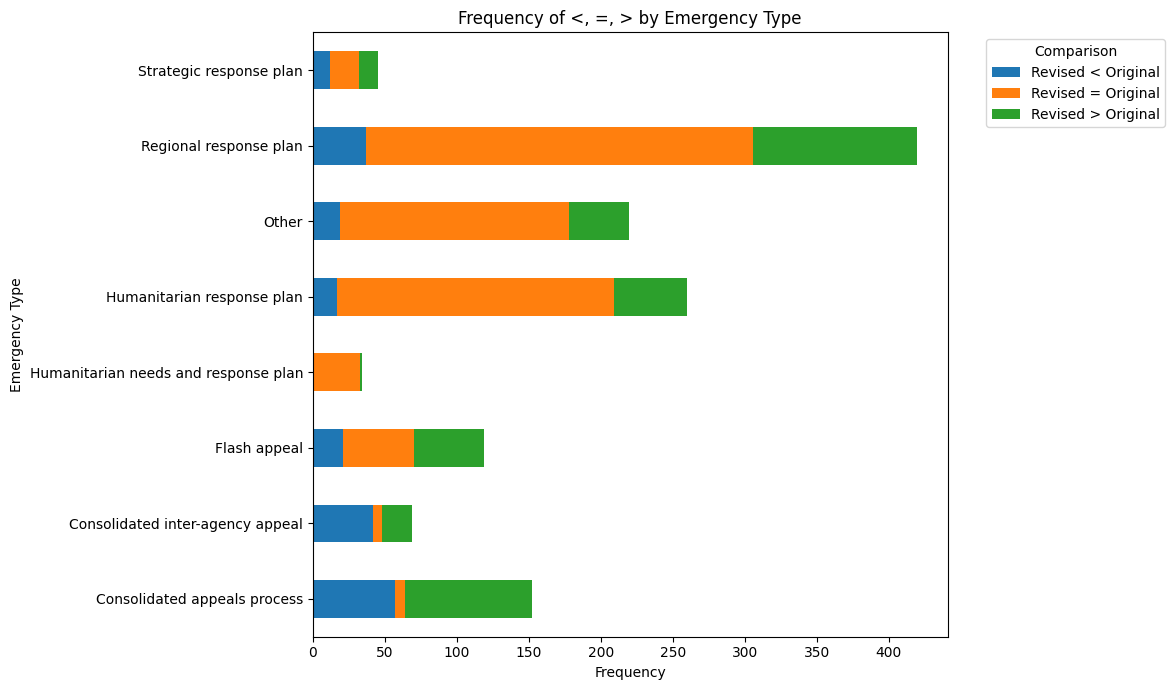

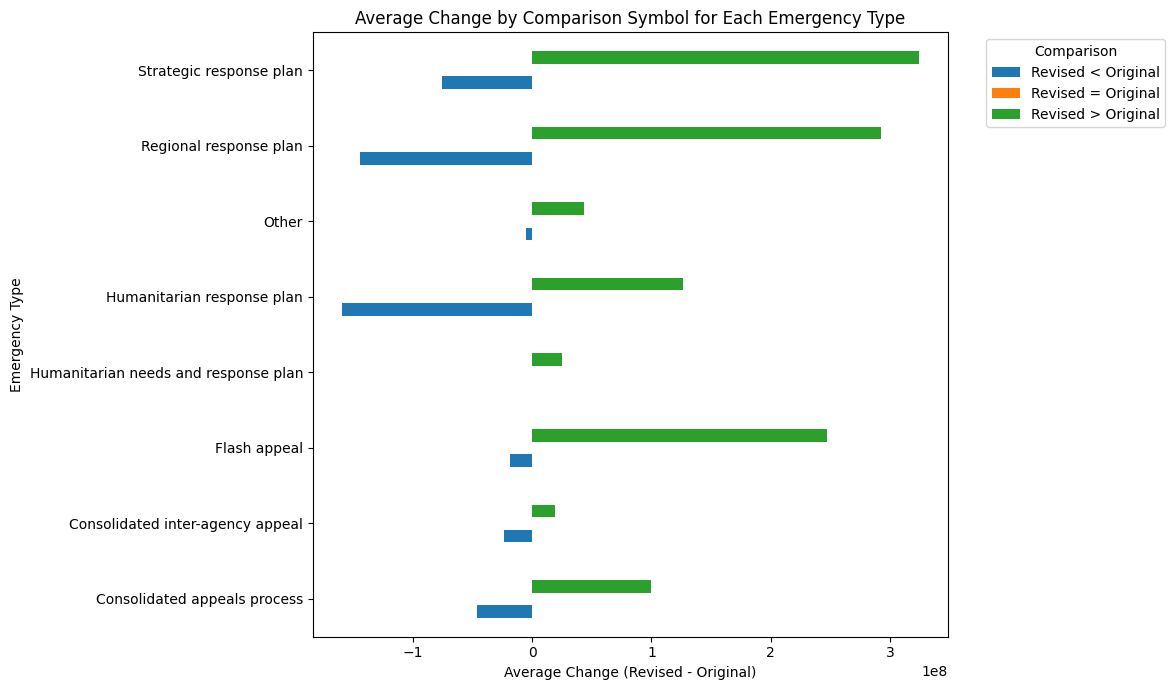

In [0]:
import matplotlib.pyplot as plt

# Emergency type abbreviations
em_type_abbr = {
    "Natural Disaster": "ND",
    "Conflict": "CF",
    "Epidemic": "EP",
    "Strategic Response Plan": "Strategic RP",
}
df['em_type_abbr'] = df['emergency_type'].map(em_type_abbr).fillna(df['emergency_type'])

# Count frequencies of <,=,> for each response_type
freq_df = df.groupby(['em_type_abbr', 'comparison']).size().reset_index(name='count')
pivot_freq = freq_df.pivot(index='em_type_abbr', columns='comparison', values='count').fillna(0)

pivot_freq.plot(kind='barh', stacked=True, figsize=(12, 7))
plt.ylabel('Emergency Type')
plt.xlabel('Frequency')
plt.title('Frequency of <, =, > by Emergency Type')
plt.legend(title='Comparison', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot average change by response_type for each comparison symbol
avg_change = df.groupby(['em_type_abbr', 'comparison'])['change'].mean().reset_index()
pivot_change = avg_change.pivot(index='em_type_abbr', columns='comparison', values='change').fillna(0)

pivot_change.plot(kind='barh', figsize=(12, 7))
plt.ylabel('Emergency Type')
plt.xlabel('Average Change (Revised - Original)')
plt.title('Average Change by Comparison Symbol for Each Emergency Type')
plt.legend(title='Comparison', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Index(['startDate', 'endDate', 'origRequirements', 'revisedRequirements',
       'locations', 'year', 'duration', 'comparison', 'emergency_type',
       'response_type', 'Country ISO3', 'proportion_in_need', 'change'],
      dtype='object')


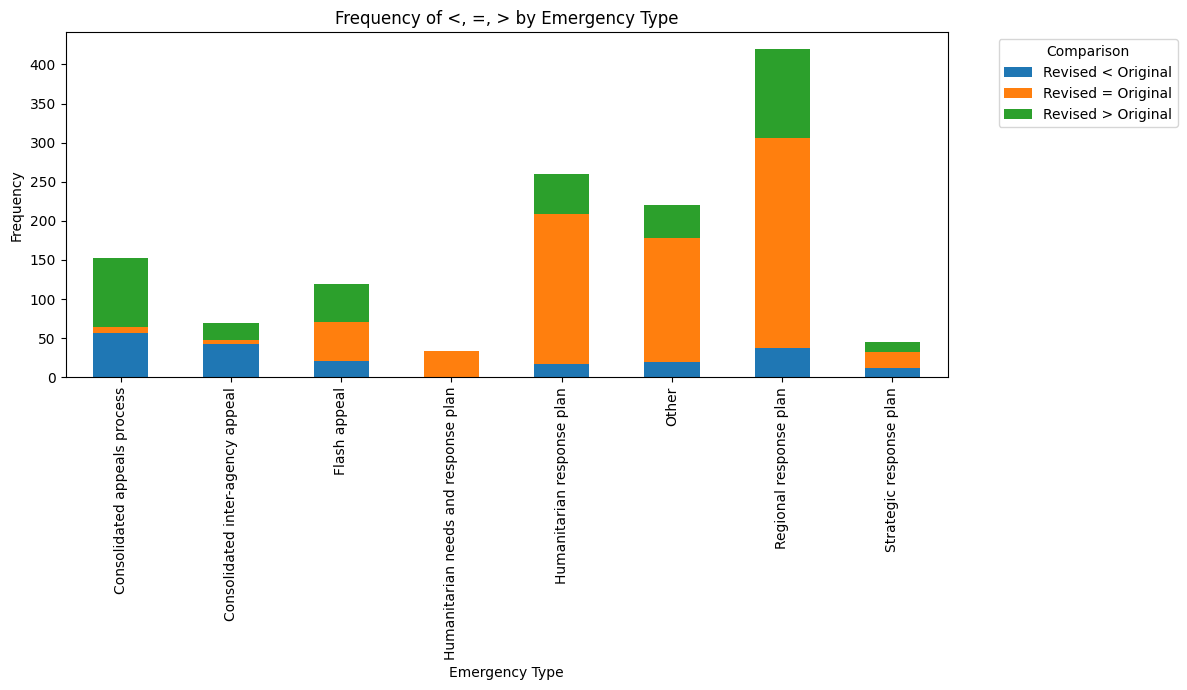

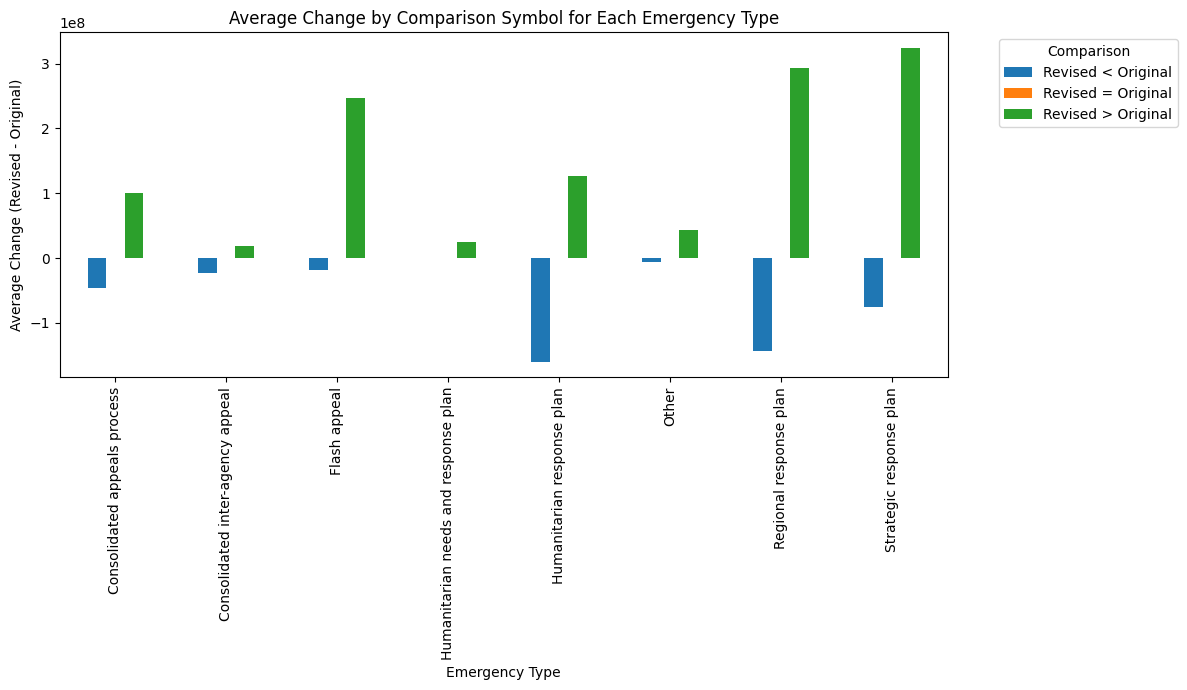

In [0]:
import matplotlib.pyplot as plt

# Add the missing 'change' column
# Minimal fix: difference between revised and original requirements
if 'change' not in df.columns:
    df['change'] = df['revisedRequirements'].astype(float) - df['origRequirements'].astype(float)

# Check available columns
print(df.columns)  # Ensure 'response_type', 'comparison', 'change' are present

# Count frequencies of <,=,> for each response_type
freq_df = df.groupby(['emergency_type', 'comparison']).size().reset_index(name='count')
pivot_freq = freq_df.pivot(index='emergency_type', columns='comparison', values='count').fillna(0)

pivot_freq.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.xlabel('Emergency Type')
plt.ylabel('Frequency')
plt.title('Frequency of <, =, > by Emergency Type')
plt.legend(title='Comparison', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot average change by response_type for each comparison symbol
avg_change = df.groupby(['emergency_type', 'comparison'])['change'].mean().reset_index()
pivot_change = avg_change.pivot(index='emergency_type', columns='comparison', values='change').fillna(0)

pivot_change.plot(kind='bar', figsize=(12, 7))
plt.xlabel('Emergency Type')
plt.ylabel('Average Change (Revised - Original)')
plt.title('Average Change by Comparison Symbol for Each Emergency Type')
plt.legend(title='Comparison', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Index(['startDate', 'endDate', 'origRequirements', 'revisedRequirements',
       'locations', 'year', 'duration', 'comparison', 'emergency_type',
       'response_type', 'Country ISO3', 'proportion_in_need', 'change'],
      dtype='object')


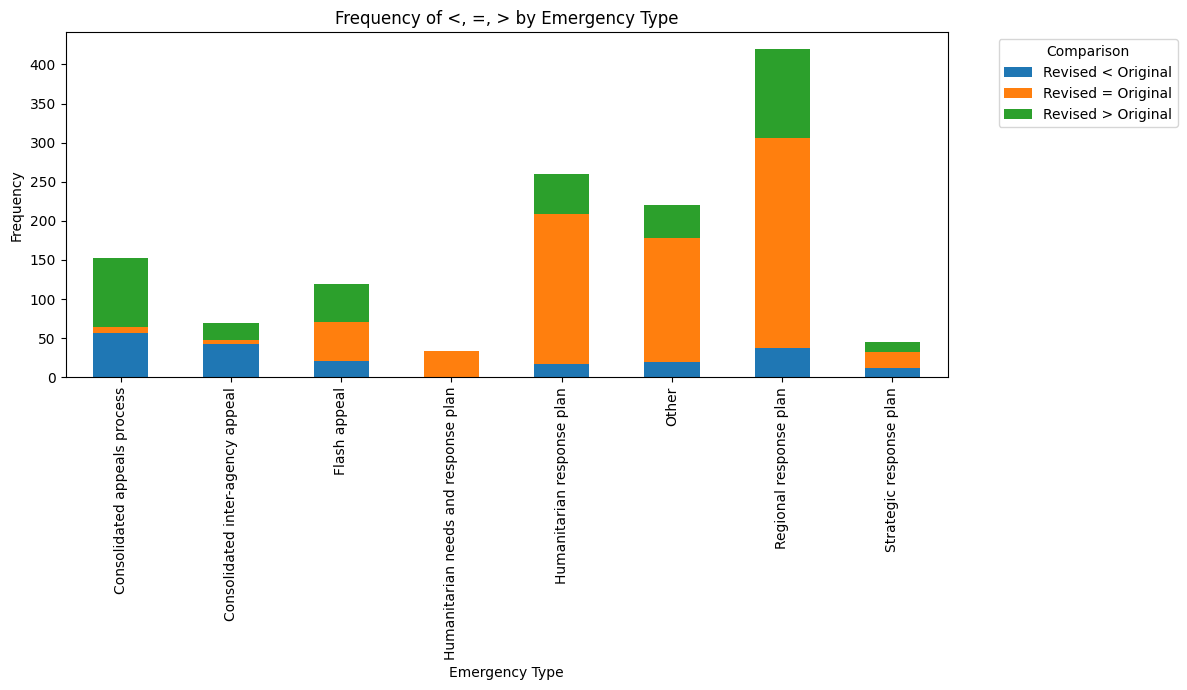

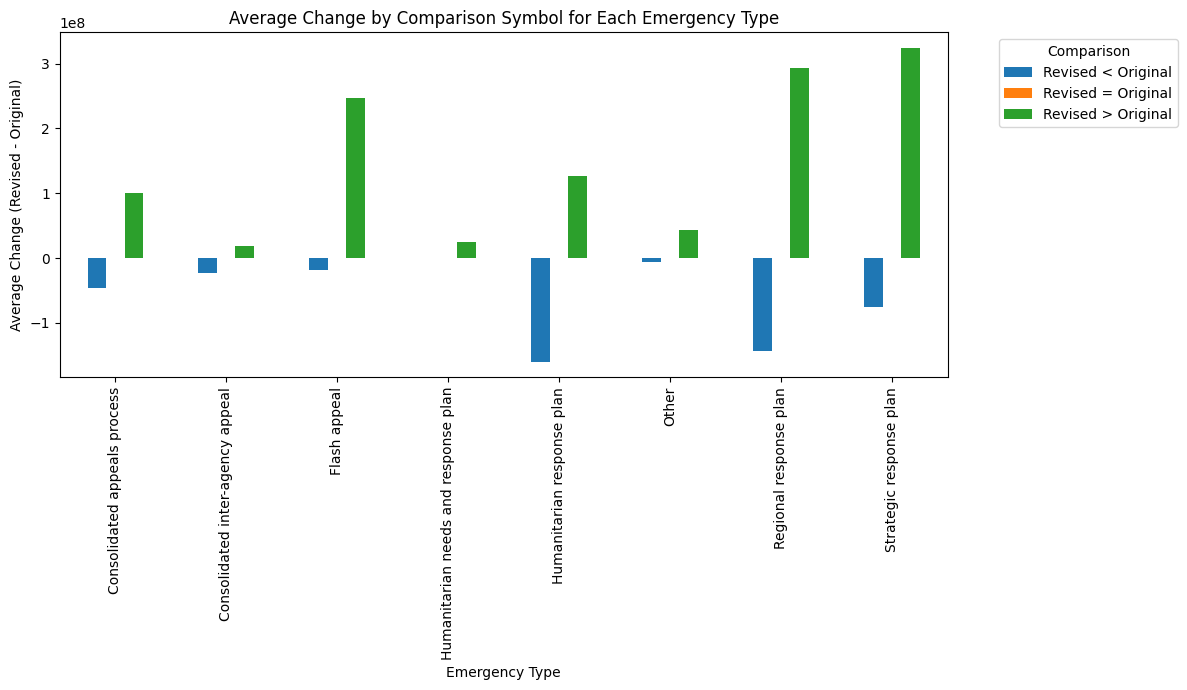

In [0]:
import matplotlib.pyplot as plt

# Add the missing 'change' column
# Minimal fix: difference between revised and original requirements
if 'change' not in df.columns:
    df['change'] = df['revisedRequirements'].astype(float) - df['origRequirements'].astype(float)

# Check available columns
print(df.columns)  # Ensure 'response_type', 'comparison', 'change' are present

# Count frequencies of <,=,> for each response_type
freq_df = df.groupby(['emergency_type', 'comparison']).size().reset_index(name='count')
pivot_freq = freq_df.pivot(index='emergency_type', columns='comparison', values='count').fillna(0)

pivot_freq.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.xlabel('Emergency Type')
plt.ylabel('Frequency')
plt.title('Frequency of <, =, > by Emergency Type')
plt.legend(title='Comparison', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot average change by response_type for each comparison symbol
avg_change = df.groupby(['emergency_type', 'comparison'])['change'].mean().reset_index()
pivot_change = avg_change.pivot(index='emergency_type', columns='comparison', values='change').fillna(0)

pivot_change.plot(kind='bar', figsize=(12, 7))
plt.xlabel('Emergency Type')
plt.ylabel('Average Change (Revised - Original)')
plt.title('Average Change by Comparison Symbol for Each Emergency Type')
plt.legend(title='Comparison', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

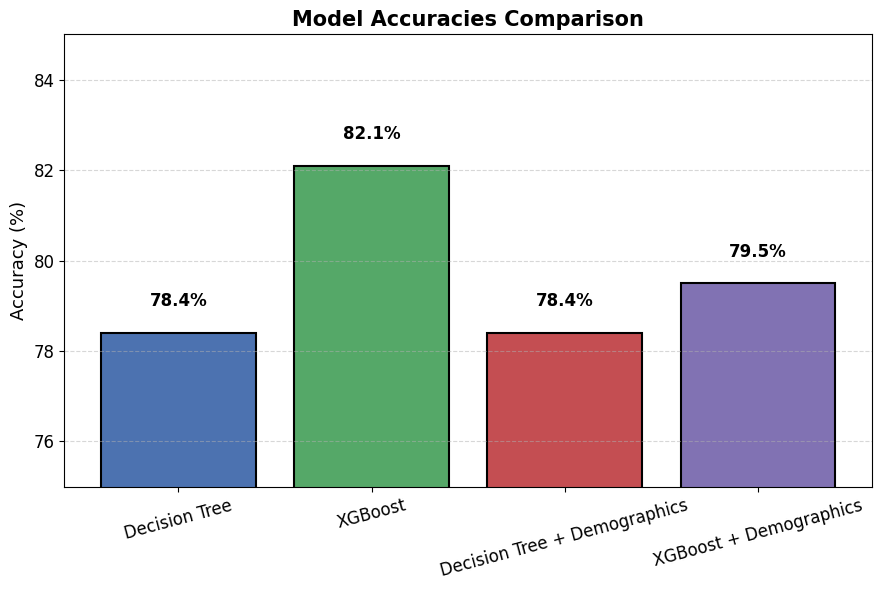

In [0]:
import matplotlib.pyplot as plt

models = [
    "Decision Tree",
    "XGBoost",
    "Decision Tree + Demographics",
    "XGBoost + Demographics"
]
accuracies = [78.4, 82.1, 78.4, 79.5]

plt.figure(figsize=(9, 6))
bars = plt.bar(models, accuracies, color=['#4C72B0', '#55A868', '#C44E52', '#8172B3'], edgecolor='black', linewidth=1.5)
plt.ylabel('Accuracy (%)', fontsize=13)
plt.title('Model Accuracies Comparison', fontsize=15, fontweight='bold')
plt.ylim(75, 85)
plt.xticks(rotation=15, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{acc:.1f}%", ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

plt.tight_layout()
plt.show()